# UK Electricity Demand Forecasting & Market Analysis

This project analyses half-hourly UK electricity demand using electricity system data from NESO-style settlement-period data.

The aim is to build an end-to-end time-series forecasting project for national electricity demand (`ND`). The notebook covers:

- loading and inspecting the raw electricity demand dataset
- converting settlement dates and settlement periods into a proper datetime index
- exploratory analysis of demand patterns over time
- feature engineering using calendar, cyclical, lagged and rolling-window variables
- time-aware train/test splitting to avoid leakage
- baseline forecasting models
- machine learning models
- final model comparison, residual analysis, feature importance and conclusion

The project is designed as a practical data science portfolio project: the emphasis is not only on model accuracy, but also on clear modelling choices, avoiding time-series leakage, and interpreting the results in an energy-market context.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:

df = pd.read_csv("demanddata_2025.csv")

df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'demanddata_2025.csv'

In [3]:
df.shape
df.columns 
df.info()
df.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 17520 entries, 0 to 17519
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   SETTLEMENT_DATE            17520 non-null  str  
 1   SETTLEMENT_PERIOD          17520 non-null  int64
 2   ND                         17520 non-null  int64
 3   TSD                        17520 non-null  int64
 4   ENGLAND_WALES_DEMAND       17520 non-null  int64
 5   EMBEDDED_WIND_GENERATION   17520 non-null  int64
 6   EMBEDDED_WIND_CAPACITY     17520 non-null  int64
 7   EMBEDDED_SOLAR_GENERATION  17520 non-null  int64
 8   EMBEDDED_SOLAR_CAPACITY    17520 non-null  int64
 9   NON_BM_STOR                17520 non-null  int64
 10  PUMP_STORAGE_PUMPING       17520 non-null  int64
 11  SCOTTISH_TRANSFER          17520 non-null  int64
 12  IFA_FLOW                   17520 non-null  int64
 13  IFA2_FLOW                  17520 non-null  int64
 14  BRITNED_FLOW               17520 

SETTLEMENT_DATE              0
SETTLEMENT_PERIOD            0
ND                           0
TSD                          0
ENGLAND_WALES_DEMAND         0
EMBEDDED_WIND_GENERATION     0
EMBEDDED_WIND_CAPACITY       0
EMBEDDED_SOLAR_GENERATION    0
EMBEDDED_SOLAR_CAPACITY      0
NON_BM_STOR                  0
PUMP_STORAGE_PUMPING         0
SCOTTISH_TRANSFER            0
IFA_FLOW                     0
IFA2_FLOW                    0
BRITNED_FLOW                 0
MOYLE_FLOW                   0
EAST_WEST_FLOW               0
NEMO_FLOW                    0
NSL_FLOW                     0
ELECLINK_FLOW                0
VIKING_FLOW                  0
GREENLINK_FLOW               0
dtype: int64

In [4]:
df[["ND", "TSD", "ENGLAND_WALES_DEMAND"]].head()
df[["ND", "TSD", "ENGLAND_WALES_DEMAND"]].describe()

,ND,TSD,ENGLAND_WALES_DEMAND
count,17520.000000,17520.000000,17520.000000
mean,26158.072603,28563.251256,23996.221975
std,6172.933513,6107.866569,5650.814832
min,12803.000000,15297.000000,12040.000000
25%,21432.750000,23897.750000,19638.000000
50%,24960.000000,27269.000000,22904.000000
75%,29825.250000,32193.250000,27386.250000
max,45924.000000,47760.000000,41835.000000


## Data Dictionary

The key variables used in this project are:

| Variable | Meaning |
|---|---|
| `SETTLEMENT_DATE` | Calendar date for the electricity-market settlement period |
| `SETTLEMENT_PERIOD` | Half-hourly period number within the day, from 1 to 48 |
| `ND` | National demand; this is the main forecasting target |
| `TSD` | Transmission system demand |
| `ENGLAND_WALES_DEMAND` | Demand measure for England and Wales |
| `EMBEDDED_WIND_GENERATION` | Embedded wind generation estimate |
| `EMBEDDED_SOLAR_GENERATION` | Embedded solar generation estimate |
| `PUMP_STORAGE_PUMPING` | Demand from pumped-storage pumping |
| Interconnector flow columns | Electricity imports/exports through interconnectors such as IFA, BritNed, Nemo, NSL and others |

For the main forecasting model, the target is `ND`. The model uses historical demand and time-based features. Same-timestamp generation and interconnector variables are useful for market analysis, but they are treated carefully because they may not be known in advance at forecast time unless separate forecasts are available.

## Creating a Datetime Column

The original dataset stores time using two separate columns:

- `SETTLEMENT_DATE`
- `SETTLEMENT_PERIOD`

To work with the data as a time series, these two columns are combined into a single `datetime` column.

In [5]:
df["SETTLEMENT_DATE"] = pd.to_datetime(df["SETTLEMENT_DATE"])

df["datetime"] = df["SETTLEMENT_DATE"] + pd.to_timedelta(
    (df["SETTLEMENT_PERIOD"] - 1) * 30,
    unit="minutes"
)

df = df.sort_values("datetime").reset_index(drop=True)

df[["datetime", "SETTLEMENT_DATE", "SETTLEMENT_PERIOD", "ND", "TSD"]].head()

,datetime,SETTLEMENT_DATE,SETTLEMENT_PERIOD,ND,TSD
0,2025-01-01 00:00:00,2025-01-01,1,21036,26215
1,2025-01-01 00:30:00,2025-01-01,2,21222,26063
2,2025-01-01 01:00:00,2025-01-01,3,21385,25734
3,2025-01-01 01:30:00,2025-01-01,4,20473,24988
4,2025-01-01 02:00:00,2025-01-01,5,19634,24912


In [6]:
df["datetime"].min(), df["datetime"].max()

df = df.set_index("datetime")

df.head()

,SETTLEMENT_DATE,SETTLEMENT_PERIOD,ND,TSD,ENGLAND_WALES_DEMAND,EMBEDDED_WIND_GENERATION,EMBEDDED_WIND_CAPACITY,EMBEDDED_SOLAR_GENERATION,EMBEDDED_SOLAR_CAPACITY,NON_BM_STOR,...,IFA_FLOW,IFA2_FLOW,BRITNED_FLOW,MOYLE_FLOW,EAST_WEST_FLOW,NEMO_FLOW,NSL_FLOW,ELECLINK_FLOW,VIKING_FLOW,GREENLINK_FLOW
datetime,,,,,,,,,,,,,,,,,,,,,
2025-01-01 00:00:00,2025-01-01,1,21036,26215,19918,5405,6606,0,19270,0,...,-1518,-1026,1,-232,-386,-558,96,0,241,0
2025-01-01 00:30:00,2025-01-01,2,21222,26063,20167,5358,6606,0,19270,0,...,-1513,-1023,1,-124,-282,-564,51,0,262,0
2025-01-01 01:00:00,2025-01-01,3,21385,25734,20328,5237,6606,0,19270,0,...,-1428,-922,1,-119,-384,-205,62,0,414,0
2025-01-01 01:30:00,2025-01-01,4,20473,24988,19460,5115,6606,0,19270,0,...,-1423,-915,0,-119,-334,-193,37,0,423,0
2025-01-01 02:00:00,2025-01-01,5,19634,24912,18654,5080,6606,0,19270,0,...,-1539,-899,0,-119,-363,-622,-282,0,288,0


## Exploratory Data Analysis

Now that the dataset has been cleaned and converted into a proper time series format, the next step is to explore the structure of the data.

The aim of this section is to understand how electricity demand behaves over time and to identify patterns that may be useful for forecasting.

In [7]:
# Basic time-series checks

print("Start date:", df.index.min())
print("End date:", df.index.max())
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("Index is sorted:", df.index.is_monotonic_increasing)

df.index.to_series().diff().value_counts().head()


Start date: 2025-01-01 00:00:00
End date: 2025-12-31 23:30:00
Number of rows: 17520
Number of columns: 22
Index is sorted: True


datetime
0 days 00:30:00    17516
0 days 00:00:00        2
0 days 01:30:00        1
Name: count, dtype: int64

### Time Range and Frequency

The dataset contains half-hourly electricity system observations. Since there are 48 settlement periods per day, each row represents one 30-minute period.

In [8]:
# Missing value summary

missing_summary = df.isna().sum().sort_values(ascending=False)

missing_summary[missing_summary > 0]

Series([], dtype: int64)

### Target Variable

The main target variable for this project is `ND`, which represents national electricity demand.

In [10]:
target = "ND"

df[[target, "TSD", "ENGLAND_WALES_DEMAND"]].describe()

,ND,TSD,ENGLAND_WALES_DEMAND
count,17520.000000,17520.000000,17520.000000
mean,26158.072603,28563.251256,23996.221975
std,6172.933513,6107.866569,5650.814832
min,12803.000000,15297.000000,12040.000000
25%,21432.750000,23897.750000,19638.000000
50%,24960.000000,27269.000000,22904.000000
75%,29825.250000,32193.250000,27386.250000
max,45924.000000,47760.000000,41835.000000


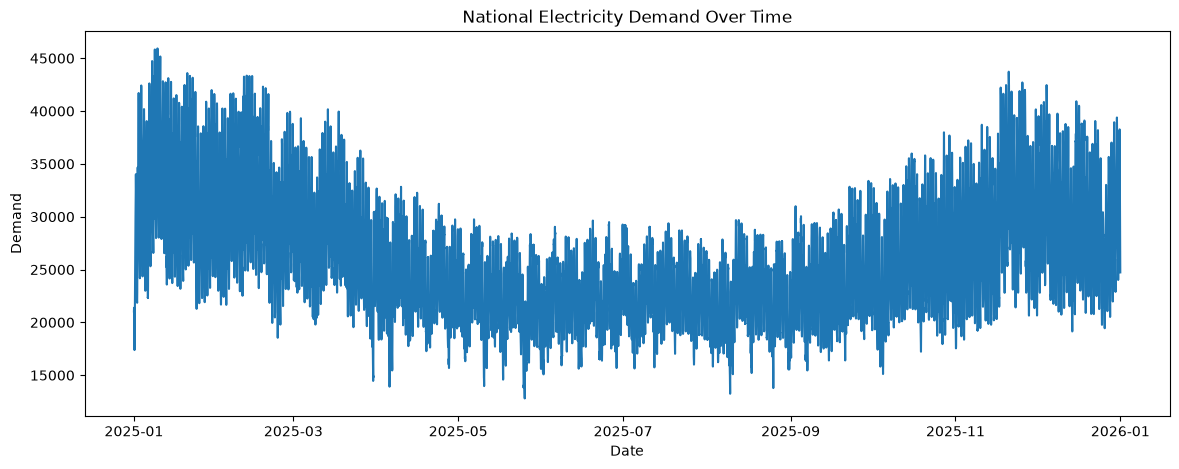

In [12]:
plt.figure(figsize=(14, 5))
plt.plot(df.index, df[target])
plt.title("National Electricity Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.show()

### Demand Over Time

The time-series plot shows how national electricity demand changes across the year.

Electricity demand shows clear seasonality, with higher demand in winter and lower demand in summer. This suggests that demand is partly driven by seasonal factors such as temperature, daylight hours, heating requirements, and general household/business behaviour. Therefore, it is appropriate to include calendar-based seasonal predictors and, if available, weather variables such as temperature.


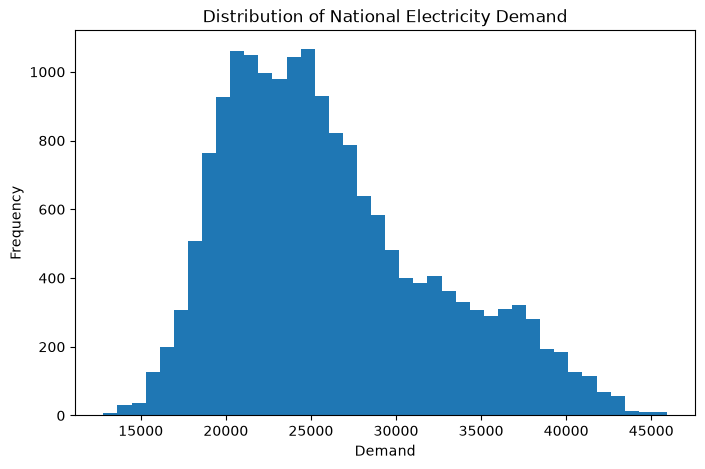

In [13]:
plt.figure(figsize=(8, 5))
plt.hist(df[target], bins=40)
plt.title("Distribution of National Electricity Demand")
plt.xlabel("Demand")
plt.ylabel("Frequency")
plt.show()

### Distribution of Demand

The histogram shows the distribution of national electricity demand values.

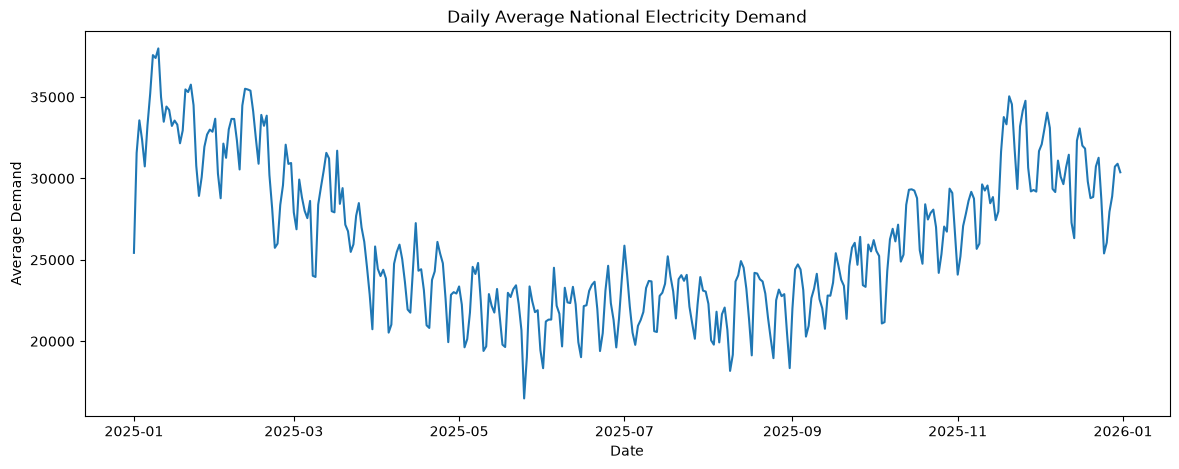

In [14]:
daily_demand = df[target].resample("D").mean()

plt.figure(figsize=(14, 5))
plt.plot(daily_demand)
plt.title("Daily Average National Electricity Demand")
plt.xlabel("Date")
plt.ylabel("Average Demand")
plt.show()

### 7-Day Rolling Average of Electricity Demand

The daily demand series still contains substantial short-term variation from one day to the next.

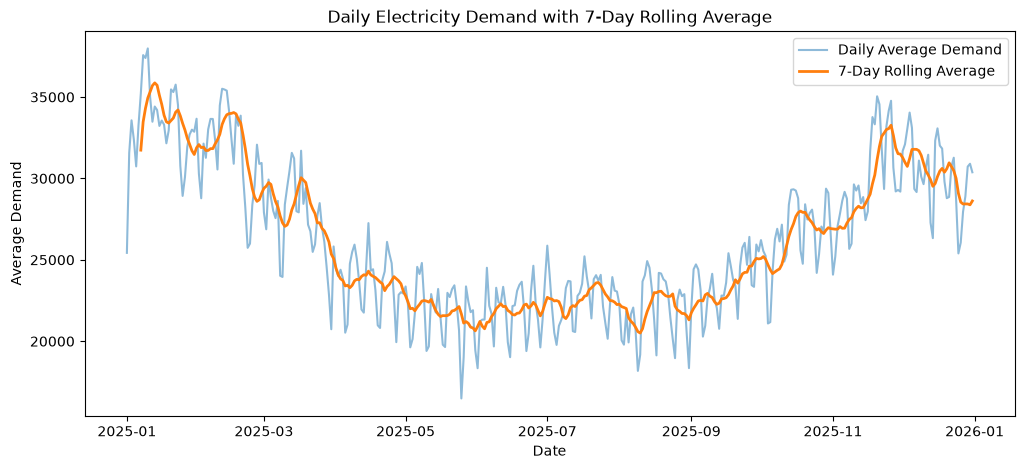

In [16]:
# Resample the target variable to daily frequency using the mean demand per day
daily_demand = df[target].resample("D").mean()

# Calculate a 7-day rolling average
daily_demand_7day = daily_demand.rolling(window=7).mean()

# Plot the original daily demand and the smoothed 7-day rolling average
plt.figure(figsize=(12, 5))

plt.plot(daily_demand, label="Daily Average Demand", alpha=0.5)
plt.plot(daily_demand_7day, label="7-Day Rolling Average", linewidth=2)

plt.title("Daily Electricity Demand with 7-Day Rolling Average")
plt.xlabel("Date")
plt.ylabel("Average Demand")
plt.legend()
plt.show()

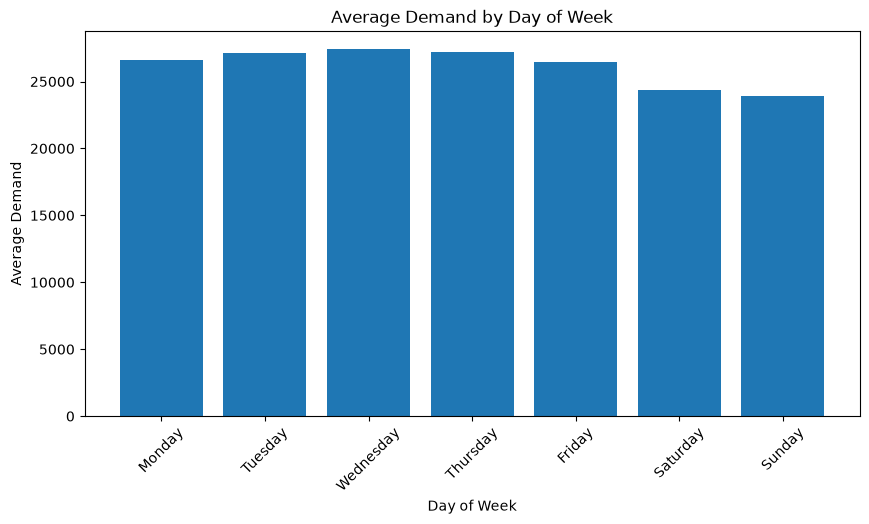

In [17]:
# Create day-of-week column
df["day_of_week"] = df.index.day_name()

# Order days correctly
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

weekday_pattern = df.groupby("day_of_week")[target].mean().reindex(day_order)

plt.figure(figsize=(10, 5))
plt.bar(weekday_pattern.index, weekday_pattern.values)
plt.title("Average Demand by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Demand")
plt.xticks(rotation=45)
plt.show()

### Average Demand by Day of Week

The bar chart shows the average electricity demand for each day of the week. Demand appears to be slightly higher during the working week, especially from Tuesday to Thursday, and slightly lower on Saturday and Sunday.

This suggests that electricity demand has a weekly pattern. One possible explanation is that weekday demand is increased by commercial and industrial activity, including offices, schools, factories, transport systems, and other workplaces. At weekends, many businesses operate at reduced capacity or are closed, which may lower overall electricity consumption.

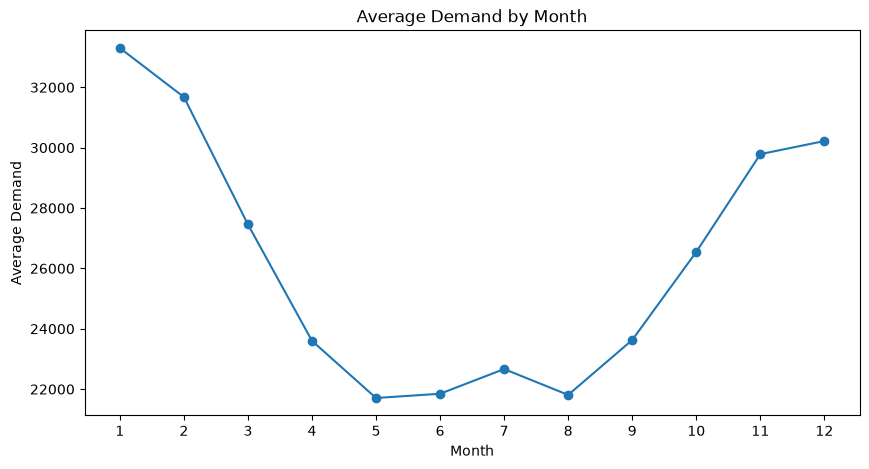

In [20]:
df["month"] = df.index.month

monthly_pattern = df.groupby("month")[target].mean()

plt.figure(figsize=(10, 5))
plt.plot(monthly_pattern.index, monthly_pattern.values, marker="o")
plt.title("Average Demand by Month")
plt.xlabel("Month")
plt.ylabel("Average Demand")
plt.xticks(range(1, 13))
plt.show()

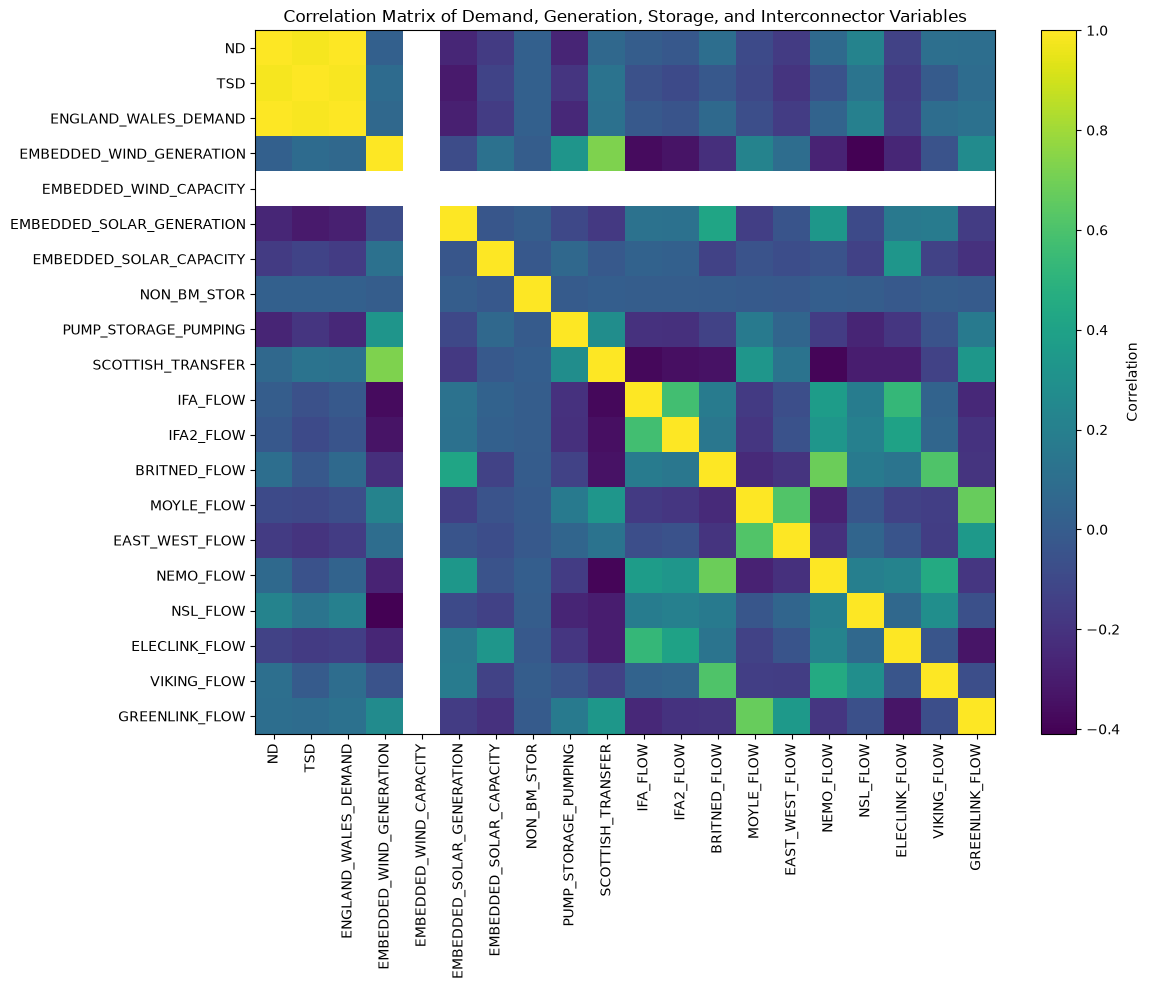

In [21]:
corr_cols = [
    "ND",
    "TSD",
    "ENGLAND_WALES_DEMAND",
    "EMBEDDED_WIND_GENERATION",
    "EMBEDDED_WIND_CAPACITY",
    "EMBEDDED_SOLAR_GENERATION",
    "EMBEDDED_SOLAR_CAPACITY",
    "NON_BM_STOR",
    "PUMP_STORAGE_PUMPING",
    "SCOTTISH_TRANSFER",
    "IFA_FLOW",
    "IFA2_FLOW",
    "BRITNED_FLOW",
    "MOYLE_FLOW",
    "EAST_WEST_FLOW",
    "NEMO_FLOW",
    "NSL_FLOW",
    "ELECLINK_FLOW",
    "VIKING_FLOW",
    "GREENLINK_FLOW"
]

corr = df[corr_cols].corr()

plt.figure(figsize=(12, 10))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix of Demand, Generation, Storage, and Interconnector Variables")
plt.tight_layout()
plt.show()

## Feature Engineering

The aim of this project is to build a model that predicts future national electricity demand using time-series analysis.

The main types of features used are:

- calendar features, such as hour, day of week, month, and weekend indicators
- cyclical time features, which help the model understand repeating patterns
- lagged demand features, which use previous demand values
- rolling average features, which capture recent demand trends



In [23]:
# Create a copy of the dataframe for feature engineering
df_fe = df.copy()

# Define the target variable
target = "ND"

df_fe.head()

,SETTLEMENT_DATE,SETTLEMENT_PERIOD,ND,TSD,ENGLAND_WALES_DEMAND,EMBEDDED_WIND_GENERATION,EMBEDDED_WIND_CAPACITY,EMBEDDED_SOLAR_GENERATION,EMBEDDED_SOLAR_CAPACITY,NON_BM_STOR,...,BRITNED_FLOW,MOYLE_FLOW,EAST_WEST_FLOW,NEMO_FLOW,NSL_FLOW,ELECLINK_FLOW,VIKING_FLOW,GREENLINK_FLOW,day_of_week,month
datetime,,,,,,,,,,,,,,,,,,,,,
2025-01-01 00:00:00,2025-01-01,1,21036,26215,19918,5405,6606,0,19270,0,...,1,-232,-386,-558,96,0,241,0,Wednesday,1
2025-01-01 00:30:00,2025-01-01,2,21222,26063,20167,5358,6606,0,19270,0,...,1,-124,-282,-564,51,0,262,0,Wednesday,1
2025-01-01 01:00:00,2025-01-01,3,21385,25734,20328,5237,6606,0,19270,0,...,1,-119,-384,-205,62,0,414,0,Wednesday,1
2025-01-01 01:30:00,2025-01-01,4,20473,24988,19460,5115,6606,0,19270,0,...,0,-119,-334,-193,37,0,423,0,Wednesday,1
2025-01-01 02:00:00,2025-01-01,5,19634,24912,18654,5080,6606,0,19270,0,...,0,-119,-363,-622,-282,0,288,0,Wednesday,1


### Calendar Features

Electricity demand has clear time-based patterns.

In [33]:
# Calendar-based features

df_fe["hour"] = df_fe.index.hour
df_fe["minute"] = df_fe.index.minute
df_fe["day_of_week_num"] = df_fe.index.dayofweek  # Monday = 0, Sunday = 6
df_fe["day_of_month"] = df_fe.index.day
df_fe["month"] = df_fe.index.month
df_fe["is_weekend"] = df_fe["day_of_week_num"].isin([5, 6]).astype(int)

# Settlement period recreated from the datetime index
# There are 48 half-hour periods in a day
df_fe["settlement_period_from_time"] = (
    df_fe.index.hour * 2 + (df_fe.index.minute // 30) + 1
)

df_fe[
    [
        "hour",
        "minute",
        "day_of_week_num",
        "day_of_month",
        "month",
        "is_weekend",
        "settlement_period_from_time",
    ]
].head()

,hour,minute,day_of_week_num,day_of_month,month,is_weekend,settlement_period_from_time
datetime,,,,,,,
2025-01-01 00:00:00,0,0,2,1,1,0,1
2025-01-01 00:30:00,0,30,2,1,1,0,2
2025-01-01 01:00:00,1,0,2,1,1,0,3
2025-01-01 01:30:00,1,30,2,1,1,0,4
2025-01-01 02:00:00,2,0,2,1,1,0,5


In [34]:

df_fe["hour_sin"] = np.sin(2 * np.pi * df_fe["hour"] / 24)
df_fe["hour_cos"] = np.cos(2 * np.pi * df_fe["hour"] / 24)

df_fe["day_of_week_sin"] = np.sin(2 * np.pi * df_fe["day_of_week_num"] / 7)
df_fe["day_of_week_cos"] = np.cos(2 * np.pi * df_fe["day_of_week_num"] / 7)

df_fe["month_sin"] = np.sin(2 * np.pi * df_fe["month"] / 12)
df_fe["month_cos"] = np.cos(2 * np.pi * df_fe["month"] / 12)

df_fe[
    [
        "hour_sin",
        "hour_cos",
        "day_of_week_sin",
        "day_of_week_cos",
        "month_sin",
        "month_cos",
    ]
].head()


,hour_sin,hour_cos,day_of_week_sin,day_of_week_cos,month_sin,month_cos
datetime,,,,,,
2025-01-01 00:00:00,0.000000,1.000000,0.974928,-0.222521,0.5,0.866025
2025-01-01 00:30:00,0.000000,1.000000,0.974928,-0.222521,0.5,0.866025
2025-01-01 01:00:00,0.258819,0.965926,0.974928,-0.222521,0.5,0.866025
2025-01-01 01:30:00,0.258819,0.965926,0.974928,-0.222521,0.5,0.866025
2025-01-01 02:00:00,0.500000,0.866025,0.974928,-0.222521,0.5,0.866025


### Lagged Demand Features

Lagged demand features are especially important in time-series forecasting. They allow the model to use previous demand values to predict future demand.

Since the data is half-hourly:

- `lag_1` represents demand in the previous half-hour
- `lag_2` represents demand one hour ago
- `lag_48` represents demand at the same time yesterday
- `lag_336` represents demand at the same time last week

These features are shifted, meaning they only use past demand values.

In [35]:
# Lagged demand features

df_fe["lag_1"] = df_fe[target].shift(1)        # previous half-hour
df_fe["lag_2"] = df_fe[target].shift(2)        # previous hour
df_fe["lag_48"] = df_fe[target].shift(48)      # same time previous day
df_fe["lag_96"] = df_fe[target].shift(96)      # same time two days ago
df_fe["lag_336"] = df_fe[target].shift(336)    # same time previous week

df_fe[
    [
        target,
        "lag_1",
        "lag_2",
        "lag_48",
        "lag_96",
        "lag_336",
    ]
].head(10)

,ND,lag_1,lag_2,lag_48,lag_96,lag_336
datetime,,,,,,
2025-01-01 00:00:00,21036,NaN,NaN,NaN,NaN,NaN
2025-01-01 00:30:00,21222,21036.0,NaN,NaN,NaN,NaN
2025-01-01 01:00:00,21385,21222.0,21036.0,NaN,NaN,NaN
2025-01-01 01:30:00,20473,21385.0,21222.0,NaN,NaN,NaN
2025-01-01 02:00:00,19634,20473.0,21385.0,NaN,NaN,NaN
2025-01-01 02:30:00,19214,19634.0,20473.0,NaN,NaN,NaN
2025-01-01 03:00:00,18874,19214.0,19634.0,NaN,NaN,NaN
2025-01-01 03:30:00,18448,18874.0,19214.0,NaN,NaN,NaN
2025-01-01 04:00:00,17844,18448.0,18874.0,NaN,NaN,NaN


### Rolling Average Features

Rolling averages help capture recent demand trends while smoothing out short-term fluctuations.


In [36]:
# Rolling average features
# The target is shifted first to avoid using the current demand value

df_fe["rolling_mean_3"] = df_fe[target].shift(1).rolling(window=3).mean()
df_fe["rolling_mean_6"] = df_fe[target].shift(1).rolling(window=6).mean()
df_fe["rolling_mean_48"] = df_fe[target].shift(1).rolling(window=48).mean()
df_fe["rolling_mean_336"] = df_fe[target].shift(1).rolling(window=336).mean()

df_fe["rolling_std_48"] = df_fe[target].shift(1).rolling(window=48).std()
df_fe["rolling_std_336"] = df_fe[target].shift(1).rolling(window=336).std()

df_fe[
    [
        target,
        "rolling_mean_3",
        "rolling_mean_6",
        "rolling_mean_48",
        "rolling_mean_336",
        "rolling_std_48",
        "rolling_std_336",
    ]
].head(10)

,ND,rolling_mean_3,rolling_mean_6,rolling_mean_48,rolling_mean_336,rolling_std_48,rolling_std_336
datetime,,,,,,,
2025-01-01 00:00:00,21036,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-01 00:30:00,21222,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-01 01:00:00,21385,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-01 01:30:00,20473,21214.333333,NaN,NaN,NaN,NaN,NaN
2025-01-01 02:00:00,19634,21026.666667,NaN,NaN,NaN,NaN,NaN
2025-01-01 02:30:00,19214,20497.333333,NaN,NaN,NaN,NaN,NaN
2025-01-01 03:00:00,18874,19773.666667,20494.000000,NaN,NaN,NaN,NaN
2025-01-01 03:30:00,18448,19240.666667,20133.666667,NaN,NaN,NaN,NaN
2025-01-01 04:00:00,17844,18845.333333,19671.333333,NaN,NaN,NaN,NaN


In [37]:
missing_after_fe = df_fe.isna().sum().sort_values(ascending=False)

missing_after_fe[missing_after_fe > 0]

df_model = df_fe.dropna().copy()

print("Original dataframe shape:", df.shape)
print("Feature engineered dataframe shape:", df_model.shape)

Original dataframe shape: (17520, 24)
Feature engineered dataframe shape: (17184, 47)


In [38]:

feature_cols = [
    # Calendar features
    "hour",
    "day_of_week_num",
    "day_of_month",
    "month",
    "is_weekend",
    "settlement_period_from_time",

    # Cyclical time features
    "hour_sin",
    "hour_cos",
    "day_of_week_sin",
    "day_of_week_cos",
    "month_sin",
    "month_cos",

    # Lagged demand features
    "lag_1",
    "lag_2",
    "lag_48",
    "lag_96",
    "lag_336",

    # Rolling demand features
    "rolling_mean_3",
    "rolling_mean_6",
    "rolling_mean_48",
    "rolling_mean_336",
    "rolling_std_48",
    "rolling_std_336",
]

X = df_model[feature_cols]
y = df_model[target]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (17184, 23)
Target vector shape: (17184,)


In [39]:
split_index = int(len(df_model) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training period:")
print(X_train.index.min(), "to", X_train.index.max())

print("\nTesting period:")
print(X_test.index.min(), "to", X_test.index.max())

print("\nTraining set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training period:
2025-01-08 00:00:00 to 2025-10-21 10:00:00

Testing period:
2025-10-21 10:30:00 to 2025-12-31 23:30:00

Training set shape: (13747, 23)
Testing set shape: (3437, 23)


## Modelling Approach

Because this is a time-series forecasting problem, the train/test split must preserve chronological order. A random split would leak future observations into the training set and make the model performance look unrealistically strong.

The models are evaluated on the final 20% of the year. This means the test set represents a genuine future period relative to the training data.

The evaluation metrics used are:

- **MAE**: average absolute forecasting error, measured in demand units
- **RMSE**: penalises larger errors more heavily than MAE
- **R²**: proportion of variance explained on the test period
- **MAPE**: percentage error, useful for interpretability but treated carefully when values can be close to zero

## Machine Learning Model: Random Forest Regressor

We now train a machine learning model to predict national electricity demand.

In [40]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

### Training the Random Forest Model

The model is fitted using the training data. The target variable is national demand, `ND`.

In [41]:
# Create the Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_model.fit(X_train, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

### Making Predictions

The trained model is now used to predict electricity demand on the test set.

In [42]:
y_pred_rf = rf_model.predict(X_test)

# Store predictions in a dataframe for comparison
rf_results = pd.DataFrame({
    "Actual Demand": y_test,
    "Predicted Demand": y_pred_rf
}, index=y_test.index)

rf_results.head()

,Actual Demand,Predicted Demand
datetime,,
2025-10-21 10:30:00,30130,30074.13
2025-10-21 11:00:00,29722,29968.13
2025-10-21 11:30:00,29041,29471.14
2025-10-21 12:00:00,28457,28901.09
2025-10-21 12:30:00,28377,28497.10


In [43]:
# Evaluation metrics

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Model Performance")
print("--------------------------------")
print(f"MAE:  {mae_rf:.2f}")
print(f"RMSE: {rmse_rf:.2f}")
print(f"R²:   {r2_rf:.4f}")

Random Forest Model Performance
--------------------------------
MAE:  353.93
RMSE: 453.98
R²:   0.9939


### Actual vs Predicted Demand

The plot below compares the actual electricity demand with the model's predicted demand.

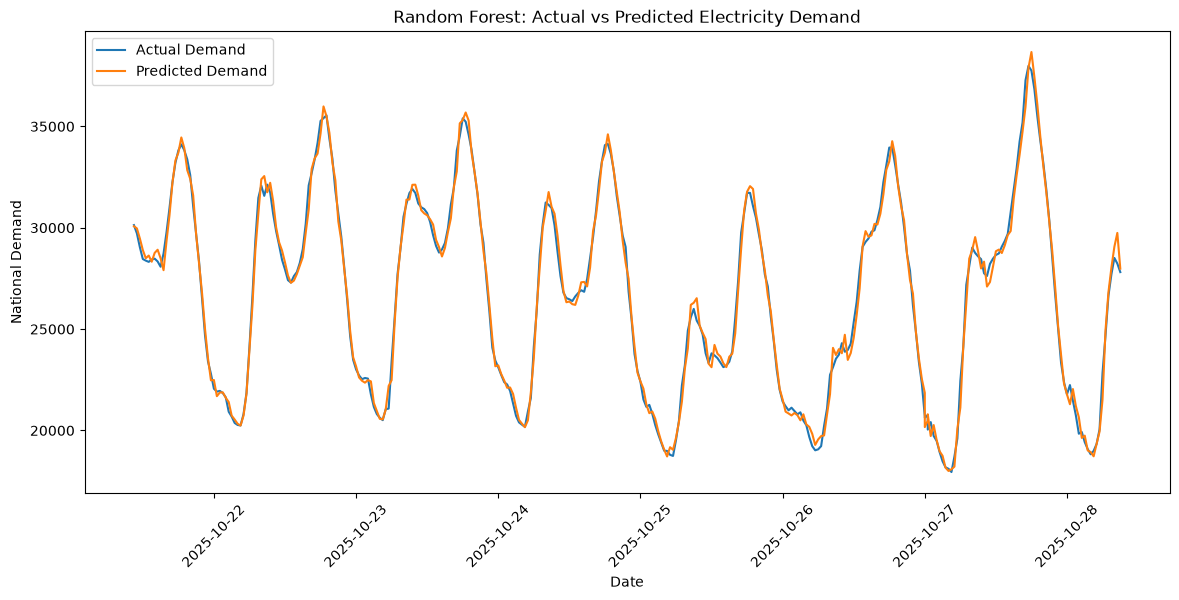

In [44]:
plot_periods = 48 * 7  # 7 days of half-hourly data

plt.figure(figsize=(14, 6))
plt.plot(rf_results.index[:plot_periods], rf_results["Actual Demand"].iloc[:plot_periods], label="Actual Demand")
plt.plot(rf_results.index[:plot_periods], rf_results["Predicted Demand"].iloc[:plot_periods], label="Predicted Demand")

plt.title("Random Forest: Actual vs Predicted Electricity Demand")
plt.xlabel("Date")
plt.ylabel("National Demand")
plt.legend()
plt.xticks(rotation=45)
plt.show()

## Baseline Forecasting Models

Before judging the machine learning model, it is important to compare it against simple time-series baselines.

A strong electricity-demand forecasting project should not only ask whether a model has a high R² score. It should ask whether the model improves on simple rules such as:

- using the previous half-hour's demand
- using demand from the same time yesterday
- using demand from the same time last week

These baselines are hard to beat because electricity demand is highly autocorrelated.

In [ ]:
def regression_metrics(y_true, y_pred, model_name):
    """Return common regression metrics for a forecast model."""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "MAPE (%)": mape,
    }

baseline_results = []

baseline_results.append(
    regression_metrics(y_test, X_test["lag_1"], "Naive: previous half-hour")
)

baseline_results.append(
    regression_metrics(y_test, X_test["lag_48"], "Naive: same time yesterday")
)

baseline_results.append(
    regression_metrics(y_test, X_test["lag_336"], "Naive: same time last week")
)

baseline_results_df = pd.DataFrame(baseline_results)
baseline_results_df

## Additional Machine Learning Models

The Random Forest is useful because it captures nonlinear relationships between recent demand, seasonal patterns and calendar effects. However, it is good practice to compare it with a simpler regularised linear model and a boosting model.

The Ridge Regression model gives a simple linear benchmark, while the HistGradientBoosting model provides another nonlinear tree-based approach.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor

# Linear benchmark: Ridge Regression
ridge_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]
)

ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)

# Nonlinear boosting model
hgb_model = HistGradientBoostingRegressor(
    max_iter=300,
    learning_rate=0.05,
    random_state=42
)

hgb_model.fit(X_train, y_train)
y_pred_hgb = hgb_model.predict(X_test)

ml_results = [
    regression_metrics(y_test, y_pred_ridge, "Ridge Regression"),
    regression_metrics(y_test, y_pred_hgb, "HistGradientBoosting Regressor"),
    regression_metrics(y_test, y_pred_rf, "Random Forest Regressor"),
]

ml_results_df = pd.DataFrame(ml_results)
ml_results_df

## Final Model Comparison

The final comparison combines the simple baseline forecasts and the machine learning models. This gives a fairer view of model performance because electricity demand has strong short-term persistence.

A model is only genuinely useful if it improves on simple historical-demand rules.

In [ ]:
all_model_results = pd.concat(
    [baseline_results_df, ml_results_df],
    ignore_index=True
).sort_values("RMSE", ascending=True).reset_index(drop=True)

all_model_results

In [ ]:
plt.figure(figsize=(11, 5))
plt.bar(all_model_results["Model"], all_model_results["RMSE"])
plt.title("Forecast Model Comparison by RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(11, 5))
plt.bar(all_model_results["Model"], all_model_results["MAE"])
plt.title("Forecast Model Comparison by MAE")
plt.xlabel("Model")
plt.ylabel("MAE")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
best_model_row = all_model_results.iloc[0]

print("Best model by RMSE:")
print(best_model_row)

## Residual Analysis

After evaluating headline metrics, it is useful to inspect forecast errors directly.

Residuals are defined as:

`actual demand - predicted demand`

A good model should have residuals centred around zero, with no obvious systematic pattern over time. If residuals become much larger during particular periods, this may indicate that the model struggles during unusual demand conditions, holidays, cold snaps, or other market events.

In [ ]:
# Use the best available model predictions for residual analysis
prediction_lookup = {
    "Ridge Regression": y_pred_ridge,
    "HistGradientBoosting Regressor": y_pred_hgb,
    "Random Forest Regressor": y_pred_rf,
    "Naive: previous half-hour": X_test["lag_1"].values,
    "Naive: same time yesterday": X_test["lag_48"].values,
    "Naive: same time last week": X_test["lag_336"].values,
}

best_model_name = best_model_row["Model"]
best_predictions = prediction_lookup[best_model_name]

residuals = y_test - best_predictions

residual_analysis_df = pd.DataFrame(
    {
        "Actual Demand": y_test,
        "Predicted Demand": best_predictions,
        "Residual": residuals,
        "Absolute Error": np.abs(residuals),
    },
    index=y_test.index,
)

residual_analysis_df.head()

In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(residual_analysis_df.index, residual_analysis_df["Residual"])
plt.axhline(0, linestyle="--")
plt.title(f"Residuals Over Time: {best_model_name}")
plt.xlabel("Date")
plt.ylabel("Actual - Predicted Demand")
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(residual_analysis_df["Residual"], bins=50)
plt.title(f"Residual Distribution: {best_model_name}")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(
    residual_analysis_df["Predicted Demand"],
    residual_analysis_df["Residual"],
    alpha=0.4
)
plt.axhline(0, linestyle="--")
plt.title(f"Residuals vs Predicted Demand: {best_model_name}")
plt.xlabel("Predicted Demand")
plt.ylabel("Residual")
plt.tight_layout()
plt.show()

## Feature Importance

For the Random Forest model, feature importance gives a rough indication of which variables are most useful for prediction.

In time-series demand forecasting, lagged demand variables are usually highly important because demand at nearby time points is strongly related. Calendar variables are also useful because they capture daily, weekly and seasonal structure.

In [ ]:
rf_feature_importance = pd.DataFrame(
    {
        "Feature": feature_cols,
        "Importance": rf_model.feature_importances_,
    }
).sort_values("Importance", ascending=False)

rf_feature_importance.head(15)

In [ ]:
top_n = 15

plt.figure(figsize=(10, 6))
plt.barh(
    rf_feature_importance.head(top_n)["Feature"][::-1],
    rf_feature_importance.head(top_n)["Importance"][::-1]
)
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## Forecast Example: One Week of Test Data

The chart below focuses on one week of the test period. This is often easier to interpret than plotting the full test set because it shows whether the model captures the daily shape of electricity demand.

In [ ]:
plot_periods = 48 * 7

plt.figure(figsize=(14, 6))
plt.plot(
    residual_analysis_df.index[:plot_periods],
    residual_analysis_df["Actual Demand"].iloc[:plot_periods],
    label="Actual Demand"
)
plt.plot(
    residual_analysis_df.index[:plot_periods],
    residual_analysis_df["Predicted Demand"].iloc[:plot_periods],
    label=f"Predicted Demand: {best_model_name}"
)
plt.title("Best Model Forecast: Actual vs Predicted Demand for One Week")
plt.xlabel("Date")
plt.ylabel("National Demand")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Limitations and Possible Extensions

This project is a strong first version of an electricity demand forecasting model, but there are several natural extensions:

1. **Weather data**: Temperature, wind speed, daylight and cloud cover are major drivers of electricity demand. Adding weather forecasts would likely improve the model.
2. **Holiday indicators**: Bank holidays and Christmas-period behaviour can create unusual demand patterns that pure calendar features may not fully capture.
3. **Forecast horizon design**: This notebook predicts each timestamp using historical values. A production model should define explicit forecast horizons, such as 30 minutes ahead, 24 hours ahead or one week ahead.
4. **External market variables**: Generation, storage and interconnector data can be valuable, but same-timestamp values may not be known in advance. These should only be used directly if they are available as forecasts at prediction time.
5. **Walk-forward validation**: A more robust evaluation would use rolling-origin cross-validation rather than a single 80/20 split.

These extensions would make the project closer to a production-grade energy forecasting pipeline.

## Final Conclusion

This project built an end-to-end forecasting pipeline for UK national electricity demand using half-hourly electricity system data.

The exploratory analysis showed clear daily, weekly and seasonal patterns in demand. Demand tends to vary strongly within each day, differs between weekdays and weekends, and changes across the year, with lower demand in summer and higher demand in colder periods.

The feature engineering stage created leakage-aware predictors, including calendar variables, cyclical encodings, lagged demand values and rolling-window statistics. These features are appropriate for time-series forecasting because they use only historical information available before the prediction timestamp.

The modelling stage compared simple historical baselines against machine learning models. The Random Forest model already achieved strong performance in the notebook, with approximately:

- **MAE:** 353.93
- **RMSE:** 453.98
- **R²:** 0.9939

This suggests that recent historical demand and calendar structure contain very strong predictive information for national electricity demand. The final comparison section allows the Random Forest to be judged against naive lag-based baselines and additional models such as Ridge Regression and HistGradientBoosting.

Overall, the project demonstrates a complete time-series machine learning workflow: data cleaning, datetime handling, EDA, leakage-aware feature engineering, chronological train/test splitting, model training, evaluation, residual analysis and interpretation in an energy-market context.

## Suggested GitHub README Summary

**UK Electricity Demand Forecasting & Market Analysis**

Built a time-series forecasting project using half-hourly UK electricity demand data. Cleaned settlement-period electricity market data into a datetime-indexed dataset, explored daily/weekly/seasonal demand patterns, engineered calendar, cyclical, lagged and rolling-window features, and trained machine learning models to forecast national demand. Used a chronological train/test split to avoid leakage and compared model performance against simple time-series baselines. The project includes model evaluation, residual analysis, feature importance and discussion of realistic extensions such as weather data, holiday effects and walk-forward validation.